In [1]:
import pandas as pd
import numpy as np
import os

In [2]:
#step 1
#load your dataset
df=pd.read_csv('Downloads/DIRTY DATA.csv')

#STEP 2; DATA EXPLORATIPON

In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Sales
0,1,11/24/2023,CUST001,Male,34,Beauty,3,50,150
1,2,2/27/2023,CUST002,Female,26,Clothing,2,500,1000
2,3,1/13/2023,CUST003,Male,50,Electronics,1,30,30
3,4,5/21/2023,CUST004,Male,37,Clothing,1,500,500
4,5,5/6/2023,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Sales
995,996,5/16/2023,CUST996,Male,62,Clothing,1,50,50
996,997,11/17/2023,CUST997,Male,52,Beauty,3,30,90
997,998,10/29/2023,CUST998,Female,23,Beauty,4,25,100
998,999,12/5/2023,CUST999,Female,36,Electronics,3,50,150
999,1000,4/12/2023,CUST1000,Male,47,Electronics,4,30,120


In [5]:
df.shape

(1000, 9)

In [6]:
df.describe()

,Transaction ID,Age
count,1000.000000,1000.00000
mean,500.500000,41.39200
std,288.819436,13.68143
min,1.000000,18.00000
25%,250.750000,29.00000
50%,500.500000,42.00000
75%,750.250000,53.00000
max,1000.000000,64.00000


In [7]:
df.dropna()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Sales
0,1,11/24/2023,CUST001,Male,34,Beauty,3,50,150
1,2,2/27/2023,CUST002,Female,26,Clothing,2,500,1000
2,3,1/13/2023,CUST003,Male,50,Electronics,1,30,30
3,4,5/21/2023,CUST004,Male,37,Clothing,1,500,500
4,5,5/6/2023,CUST005,Male,30,Beauty,2,50,100
...,...,...,...,...,...,...,...,...,...
995,996,5/16/2023,CUST996,Male,62,Clothing,1,50,50
996,997,11/17/2023,CUST997,Male,52,Beauty,3,30,90
997,998,10/29/2023,CUST998,Female,23,Beauty,4,25,100
998,999,12/5/2023,CUST999,Female,36,Electronics,3,50,150


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              997 non-null    object
 2   Customer ID       996 non-null    object
 3   Gender            999 non-null    object
 4   Age               1000 non-null   int64 
 5   Product Category  997 non-null    object
 6   Quantity          999 non-null    object
 7   Price per Unit    999 non-null    object
 8   Sales             999 non-null    object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB


In [9]:
#step3 Fix your data type
df['Price per Unit'] = pd.to_numeric(df['Price per Unit'], errors='coerce')
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Sales'] = pd.to_numeric(df['Sales'], errors="coerce")
# Convert Order_Date to datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

In [10]:
# step 4 check for missing values
df.isnull().sum()

Transaction ID      0
Date                3
Customer ID         4
Gender              1
Age                 0
Product Category    3
Quantity            3
Price per Unit      2
Sales               2
dtype: int64

In [11]:
#step 5
#filling the missing numbers

In [12]:
df['Customer ID'] =df['Customer ID'].fillna('0')

In [13]:
df['Gender'] =df['Gender'].fillna('unknown')

In [14]:
df['Product Category'] =df['Product Category'].fillna('unknown')

In [15]:
df['Quantity'] = df['Quantity'].fillna(df['Quantity'].median())

In [16]:
df['Price per Unit'] = df['Price per Unit'].fillna(df['Price per Unit'].median())

In [17]:
df['Sales'] = df['Sales'].fillna(df['Sales'].median())

In [18]:
#step 6 confirm if the missing value is filled
df.isnull().sum()

Transaction ID      0
Date                3
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Sales               0
dtype: int64

In [19]:
#step 7 checking for duplicate number
df.duplicated().sum()

np.int64(0)

In [20]:
df.drop_duplicates()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Sales
0,1,2023-11-24,CUST001,Male,34,Beauty,3.0,50.0,150.0
1,2,2023-02-27,CUST002,Female,26,Clothing,2.0,500.0,1000.0
2,3,2023-01-13,CUST003,Male,50,Electronics,1.0,30.0,30.0
3,4,2023-05-21,CUST004,Male,37,Clothing,1.0,500.0,500.0
4,5,2023-05-06,CUST005,Male,30,Beauty,2.0,50.0,100.0
...,...,...,...,...,...,...,...,...,...
995,996,2023-05-16,CUST996,Male,62,Clothing,1.0,50.0,50.0
996,997,2023-11-17,CUST997,Male,52,Beauty,3.0,30.0,90.0
997,998,2023-10-29,CUST998,Female,23,Beauty,4.0,25.0,100.0
998,999,2023-12-05,CUST999,Female,36,Electronics,3.0,50.0,150.0


In [21]:
#step8; check for unstandardize text or number

In [22]:
df['Sales'].unique()

array([ 150., 1000.,   30.,  500.,  100.,   50.,  600.,  200.,   75.,
       1500.,  135., 2000.,  900.,  120.,  300., 1200.,   90.,   25.,
         60.])

In [23]:
df['Gender'].unique()

array(['Male', 'Female', 'MALE', 'unknown', 'FEMALE'], dtype=object)

In [24]:
df['Gender'].value_counts()

Gender
Female     510
Male       486
MALE         2
unknown      1
FEMALE       1
Name: count, dtype: int64

In [25]:
df['Gender']=df['Gender'].str.lower()

In [26]:
df['Gender'].value_counts()

Gender
female     511
male       488
unknown      1
Name: count, dtype: int64

In [27]:
df['Quantity'].unique()

array([3., 2., 1., 4.])

In [28]:
df['Price per Unit'].unique()

array([ 50., 500.,  30.,  25., 300.,   0., -30.])

In [29]:
df['Sales'].unique()

array([ 150., 1000.,   30.,  500.,  100.,   50.,  600.,  200.,   75.,
       1500.,  135., 2000.,  900.,  120.,  300., 1200.,   90.,   25.,
         60.])

In [30]:
df.loc[df['Price per Unit'] < 0, 'Price per Unit'] = np.nan

In [31]:
df['Sales'].unique()

array([ 150., 1000.,   30.,  500.,  100.,   50.,  600.,  200.,   75.,
       1500.,  135., 2000.,  900.,  120.,  300., 1200.,   90.,   25.,
         60.])

In [32]:
#to change from lettr to word
df['Sales'] = df['Sales'].replace({'one hundred': 100})


In [33]:
# step 8 to check if the data type is correct
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              997 non-null    datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   float64       
 7   Price per Unit    999 non-null    float64       
 8   Sales             1000 non-null   float64       
dtypes: datetime64[ns](1), float64(3), int64(2), object(3)
memory usage: 70.4+ KB


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

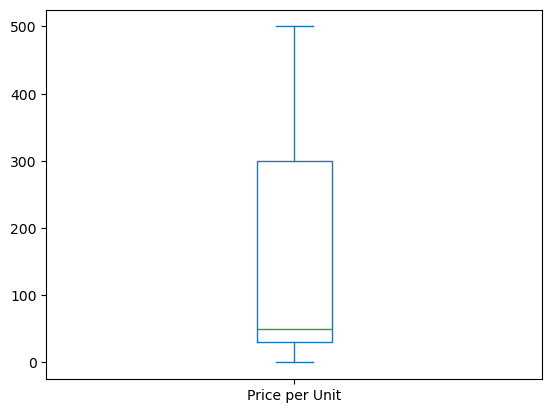

In [35]:
df['Price per Unit'].plot(kind='box')
plt.show()

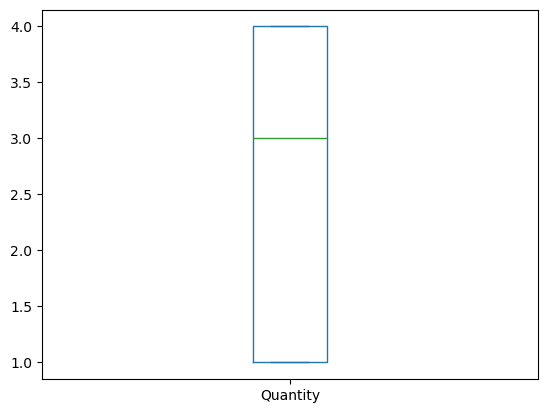

In [36]:
df['Quantity'].plot(kind='box')
plt.show()

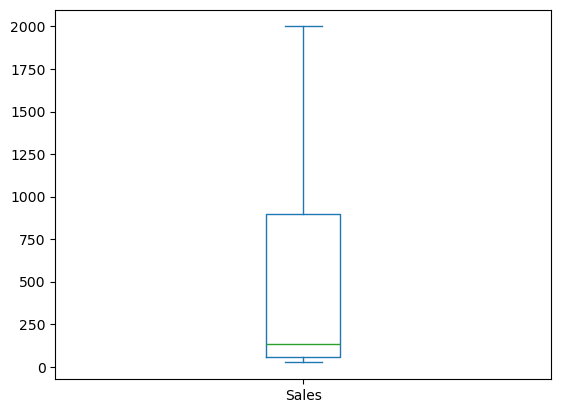

In [37]:
df['Sales'].plot(kind='box')
plt.show()

In [38]:
# if there is an oulier proceed with this code
cols = ['Age', 'Quantity', 'Price per Unit', 'Sales']

for col in cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    df = df[(df[col] >= lower) & (df[col] <= upper)]

In [39]:
df['Outlier_Flag'] = ((df['Sales'] < lower) | (df['Sales'] > upper))

In [40]:
#Save cleaned data
df.to_csv("cleaned_sales.csv", index=False)
print("Cleaning complete. Saved as cleaned_sales.csv")

Cleaning complete. Saved as cleaned_sales.csv


In [41]:
#what type of product revenue genrate more revenue

In [42]:
df['Product Category']

0           Beauty
1         Clothing
2      Electronics
3         Clothing
4           Beauty
          ...     
995       Clothing
996         Beauty
997         Beauty
998    Electronics
999    Electronics
Name: Product Category, Length: 999, dtype: object

In [43]:
df.groupby('Product Category')['Sales'].sum()

Product Category
Beauty         143515.0
Clothing       152240.0
Electronics    155705.0
unknown          3400.0
Name: Sales, dtype: float64

In [44]:
df.groupby('Product Category')['Sales'].sum().reset_index()

,Product Category,Sales
0,Beauty,143515.0
1,Clothing,152240.0
2,Electronics,155705.0
3,unknown,3400.0


In [45]:
df.groupby('Product Category')['Sales'].count().reset_index()

,Product Category,Sales
0,Beauty,307
1,Clothing,348
2,Electronics,341
3,unknown,3


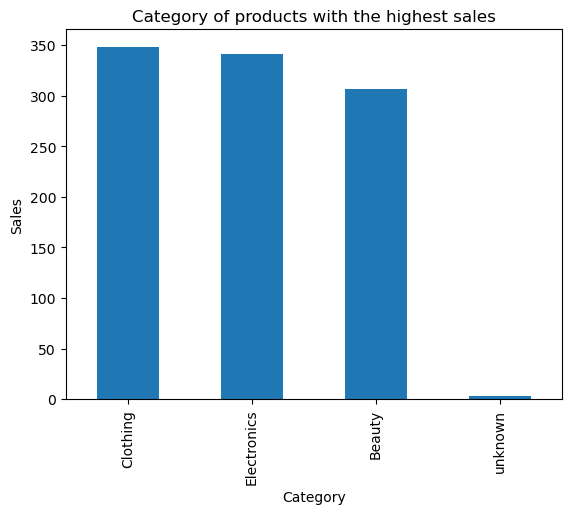

In [46]:
import matplotlib.pyplot as plt
df.groupby("Product Category")["Sales"].count().sort_values(ascending=False).head(100).plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.title("Category of products with the highest sales")
plt.show()

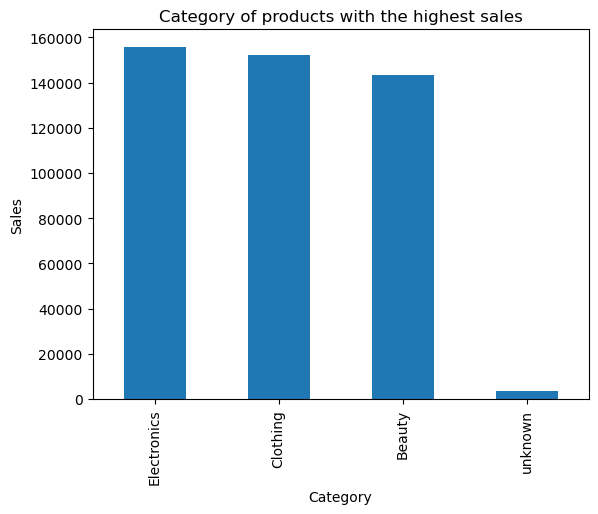

In [47]:
import matplotlib.pyplot as plt
df.groupby("Product Category")["Sales"].sum().sort_values(ascending=False).head(100).plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.title("Category of products with the highest sales")
plt.show()

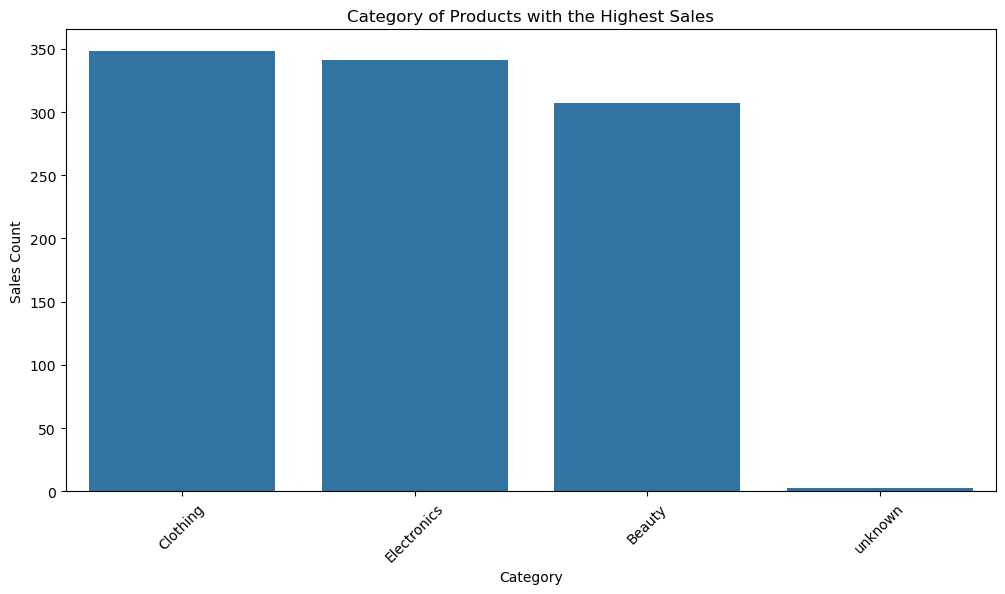

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

# Group and prepare data
category_sales = df.groupby("Product Category")["Sales"].count().sort_values(ascending=False).head(100)

# Convert to DataFrame for Seaborn
category_sales = category_sales.reset_index()

# Plot
plt.figure(figsize=(12,6))
sns.barplot(
    data=category_sales,
    x="Product Category",
    y="Sales"
)

plt.xlabel("Category")
plt.ylabel("Sales Count")
plt.title("Category of Products with the Highest Sales")
plt.xticks(rotation=45)
plt.show()

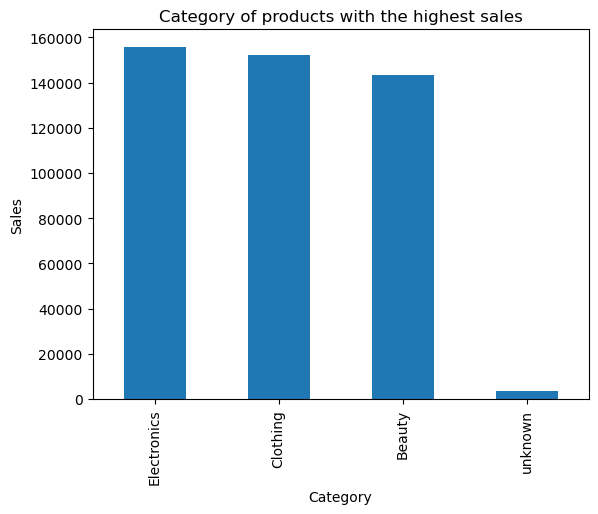

In [49]:
import matplotlib.pyplot as plt
df.groupby("Product Category")["Sales"].sum().sort_values(ascending=False).head(100).plot(kind="bar")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.title("Category of products with the highest sales")
plt.show()

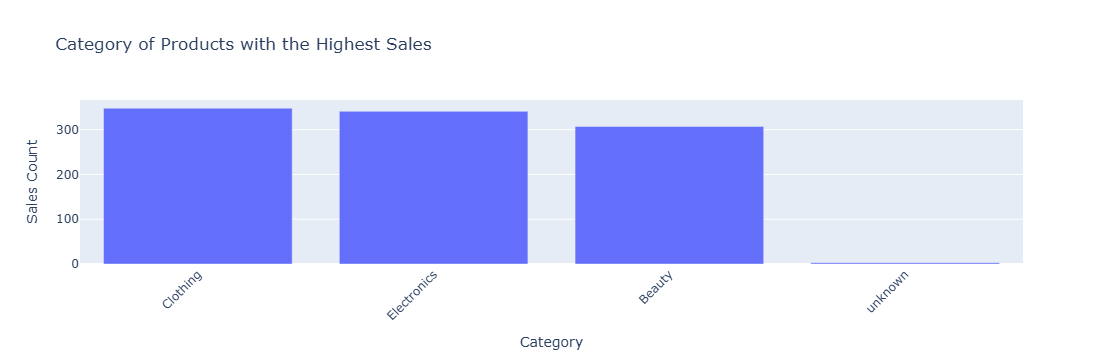

In [50]:
import plotly.express as px

# Group data
category_sales = df.groupby("Product Category")["Sales"].count().sort_values(ascending=False).head(100).reset_index()

# Create interactive bar chart
fig = px.bar(
    category_sales,
    x="Product Category",
    y="Sales",
    title="Category of Products with the Highest Sales",
    labels={"Product Category": "Category", "Sales": "Sales Count"},
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

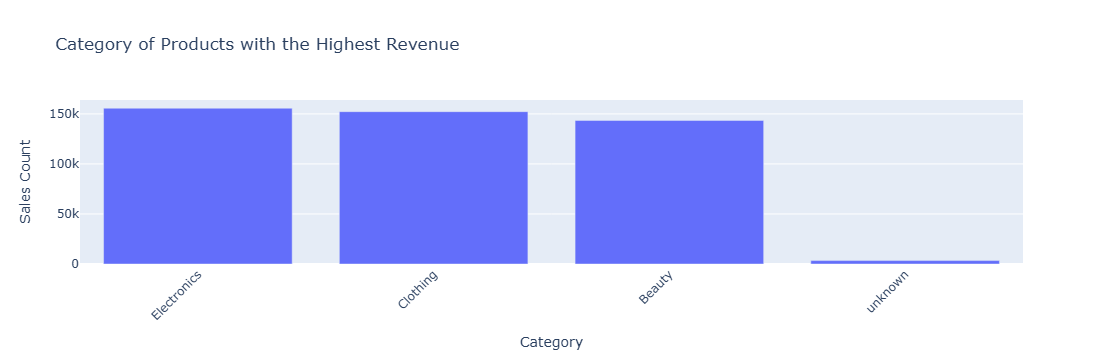

In [51]:
import plotly.express as px

# Group data
category_sales = df.groupby("Product Category")["Sales"].sum().sort_values(ascending=False).head(100).reset_index()

# Create interactive bar chart
fig = px.bar(
    category_sales,
    x="Product Category",
    y="Sales",
    title="Category of Products with the Highest Revenue",
    labels={"Product Category": "Category", "Sales": "Sales Count"},
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

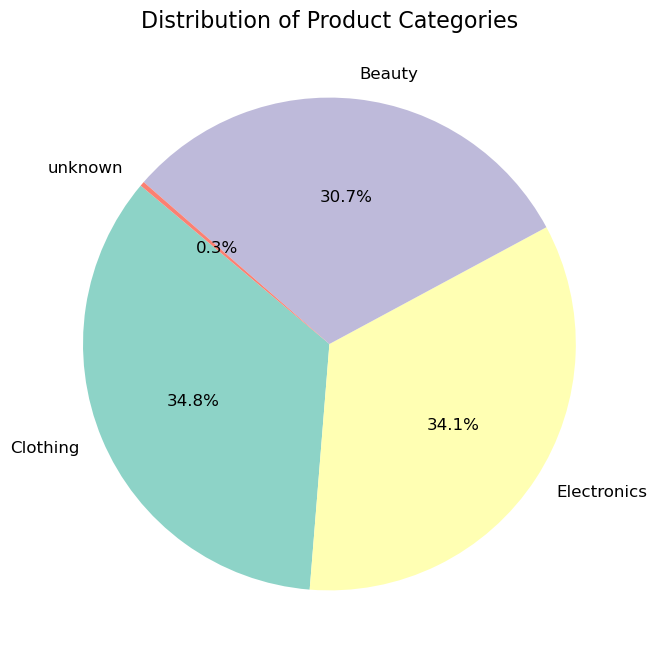

In [52]:
#Product Category Pie Chart 

category_counts = df["Product Category"].value_counts()
plt.figure(figsize=(8, 8))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', 
        colors=plt.cm.Set3.colors, startangle=140, textprops={'fontsize': 12})
plt.title('Distribution of Product Categories', fontsize=16)
plt.show()

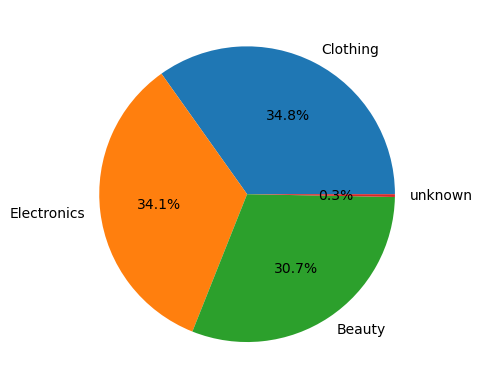

In [53]:
counts = df["Product Category"].value_counts()

plt.pie(counts, labels=counts.index, autopct="%1.1f%%")
plt.show()

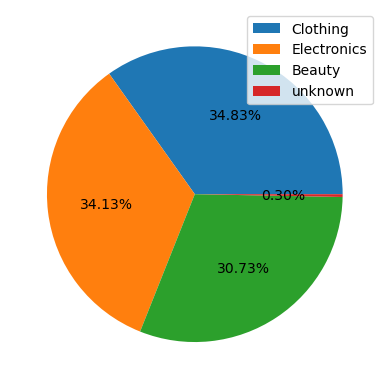

In [54]:
counts = df["Product Category"].value_counts()
plt.pie(counts, autopct="%0.002f%%")
plt.legend(counts.index)
plt.show()

In [55]:
#who are the most valuable customers


In [56]:
df.groupby('Customer ID')['Sales'].sum().reset_index()

,Customer ID,Sales
0,0,780.0
1,CUST001,150.0
2,CUST002,1000.0
3,CUST003,30.0
4,CUST004,500.0
...,...,...
991,CUST995,30.0
992,CUST996,50.0
993,CUST997,90.0
994,CUST998,100.0


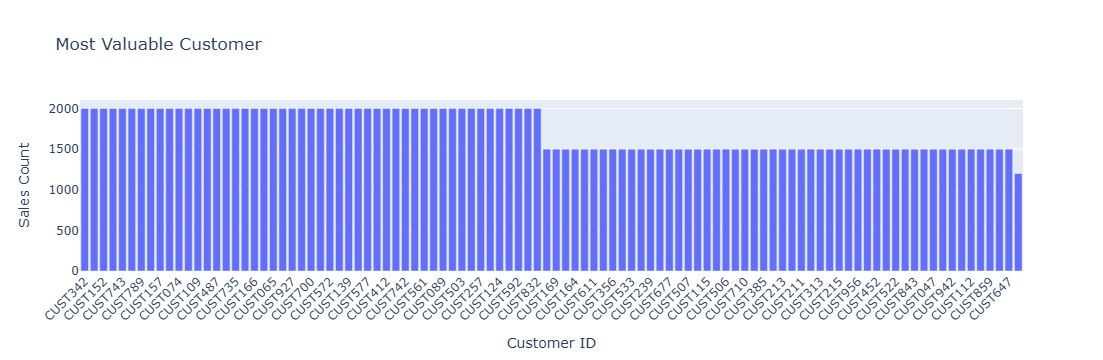

In [57]:
import plotly.express as px

# Group data
category_sales = df.groupby("Customer ID")["Sales"].sum().sort_values(ascending=False).head(100).reset_index()

# Create interactive bar chart
fig = px.bar(
    category_sales,
    x="Customer ID",
    y="Sales",
    title="Most Valuable Customer",
    labels={"Customers": "Category", "Sales": "Sales Count"},
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

In [58]:
#What drive sales: quantity or price?

“The correlation analysis shows that sales have a strong positive relationship with price per unit (0.85), meaning higher-priced products contribute more to revenue. However, quantity has a weaker relationship with sales (0.37), indicating that volume of purchases has less impact. There is almost no relationship between quantity and price, meaning pricing does not significantly influence how much customers buy.

In [59]:
df[["Sales", "Quantity", "Price per Unit"]].corr()

,Sales,Quantity,Price per Unit
Sales,1.000000,0.371887,0.850871
Quantity,0.371887,1.000000,0.019509
Price per Unit,0.850871,0.019509,1.000000


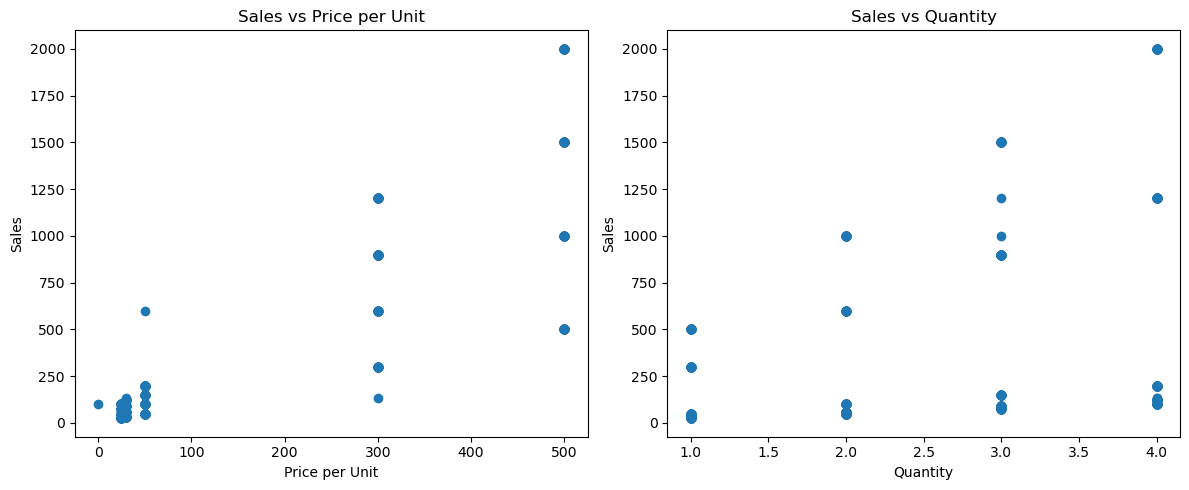

In [60]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Sales vs Price per Unit
axes[0].scatter(df["Price per Unit"], df["Sales"])
axes[0].set_title("Sales vs Price per Unit")
axes[0].set_xlabel("Price per Unit")
axes[0].set_ylabel("Sales")

# 2. Sales vs Quantity
axes[1].scatter(df["Quantity"], df["Sales"])
axes[1].set_title("Sales vs Quantity")
axes[1].set_xlabel("Quantity")
axes[1].set_ylabel("Sales")

plt.tight_layout()
plt.show()

In [61]:
#which month produce more sale

In [62]:
df.groupby('Customer ID')['Sales'].sum().reset_index()

,Customer ID,Sales
0,0,780.0
1,CUST001,150.0
2,CUST002,1000.0
3,CUST003,30.0
4,CUST004,500.0
...,...,...
991,CUST995,30.0
992,CUST996,50.0
993,CUST997,90.0
994,CUST998,100.0


In [63]:
df["Date"]=df["Date"].apply(pd.to_datetime)

In [64]:
df["Month"] = df["Date"].dt.month

In [65]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Sales,Outlier_Flag,Month
0,1,2023-11-24,CUST001,male,34,Beauty,3.0,50.0,150.0,False,11.0
1,2,2023-02-27,CUST002,female,26,Clothing,2.0,500.0,1000.0,False,2.0
2,3,2023-01-13,CUST003,male,50,Electronics,1.0,30.0,30.0,False,1.0
3,4,2023-05-21,CUST004,male,37,Clothing,1.0,500.0,500.0,False,5.0
4,5,2023-05-06,CUST005,male,30,Beauty,2.0,50.0,100.0,False,5.0


In [66]:
df.groupby('Month')['Sales'].count().reset_index()

,Month,Sales
0,1.0,77
1,2.0,85
2,3.0,73
3,4.0,86
4,5.0,104
5,6.0,77
6,7.0,72
7,8.0,94
8,9.0,65
9,10.0,96


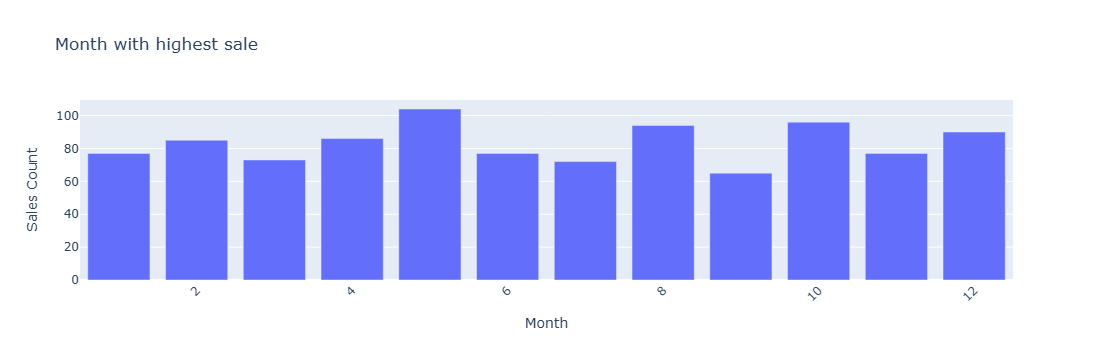

In [67]:
# Group data
category_sales = df.groupby("Month")["Sales"].count().sort_values(ascending=False).head(100).reset_index()

# Create interactive bar chart
fig = px.bar(
    category_sales,
    x="Month",
    y="Sales",
    title="Month with highest sale",
    labels={"Month with the highest Sale": "Month", "Sales": "Sales Count"},
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

In [68]:
df.groupby('Month')['Sales'].sum().reset_index()

,Month,Sales
0,1.0,34995.0
1,2.0,44060.0
2,3.0,28990.0
3,4.0,33870.0
4,5.0,53060.0
5,6.0,36715.0
6,7.0,35465.0
7,8.0,36960.0
8,9.0,22555.0
9,10.0,46580.0


In [69]:
# Group data
category_sales = df.groupby("Month")["Sales"].sum().sort_values(ascending=False).head(100).reset_index()

# Create interactive bar chart
fig = px.bar(
    category_sales,
    x="Month",
    y="Sales",
    title="Month with highest sale",
    labels={"Month with the highest Sale": "Month", "Sales": "Sales Count"},
)

fig.update_layout(
    xaxis_tickangle=-45
)

fig.show()

From the findings on our charts Month 5 which is May has the highest revenue


In [70]:
#5. where should the company focus to increase revenue?

The company should focus on Electronics because it generates the highest revenue, indicating strong value per transaction. Clothing also presents a major growth opportunity due to its high sales volume and close revenueperformance. Additionally, the company should analyzethe success factors behind Month 5, which produced the highesdt revenue, and replicate those startegies during lower - performing months such as month 9. Finally, improving categorization will enhance reporting accuracy and business decision - making.